# MIT-BIH Arrhythmia Database Analysis for CPET System

This notebook processes ECG data from the MIT-BIH Arrhythmia Database for arrhythmia detection.

**Objective:** Create a clean, centered dataset for training a CNN-based arrhythmia classifier compatible with low-cost AD8232 ECG sensors.

**Dataset:** MIT-BIH Arrhythmia Database (48 patients, ~110,000 heartbeats)

**Key Features:**
- AAMI classification (5 classes: Normal, Supraventricular, Ventricular, Fusion, Unknown/Paced)
- Pan-Tompkins R-peak detection for precise centering
- Z-score normalization for consistency

In [56]:
%pip install wfdb

Note: you may need to restart the kernel to use updated packages.


## 1. Environment Setup

Install required packages for ECG processing and analysis.

In [57]:
%pip install numpy pandas matplotlib scipy scikit-learn seaborn jupyterlab

Note: you may need to restart the kernel to use updated packages.


In [58]:
%pip install tensorflow keras

Note: you may need to restart the kernel to use updated packages.


## 2. Download MIT-BIH Database

Download the complete MIT-BIH Arrhythmia Database (48 records with annotations).

In [59]:
import wfdb
import os

# Create a directory for the data
if not os.path.exists('mit_bih_data'):
    os.makedirs('mit_bih_data')

# Download all 48 records (Patient IDs 100 to 234)
# Note: This might take a few minutes.
wfdb.dl_database('mitdb', 'mit_bih_data')

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [60]:
# Core libraries for data processing and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from scipy import signal as scipy_signal

## 4. AAMI Classification System

Define the AAMI (Association for the Advancement of Medical Instrumentation) standard for grouping ECG beat types into 5 classes.

## 3. Import Libraries

In [61]:
def load_and_segment(patient_id, window_size=180):
    """
    Load ECG data for a patient and segment it into individual heartbeats.
    
    Args:
        patient_id: Patient record ID (e.g., '100', '101')
        window_size: Number of samples per heartbeat segment (default: 180)
    
    Returns:
        X: Array of heartbeat segments (shape: num_beats x window_size)
        y: Array of beat labels/annotations
    """
    try:
        # Load the ECG record from the downloaded data
        record = wfdb.rdrecord(f'mit_bih_data/{patient_id}')
        
        # Load the annotations (R-peaks and beat types)
        annotation = wfdb.rdann(f'mit_bih_data/{patient_id}', 'atr')
        
        # Get the ECG signal (usually channel 0, MLII lead)
        signal = record.p_signal[:, 0]
        
        # Get R-peak locations and beat symbols
        r_peaks = annotation.sample
        beat_symbols = annotation.symbol
        
        X_patient = []
        y_patient = []
        
        # Extract each heartbeat around the R-peak
        for i, r_peak in enumerate(r_peaks):
            # Define the window around the R-peak
            # Take 90 samples before and 90 samples after the R-peak
            start = r_peak - window_size // 2
            end = r_peak + window_size // 2
            
            # Make sure we're within bounds
            if start >= 0 and end < len(signal):
                beat_segment = signal[start:end]
                
                # Only add if we got exactly window_size samples
                if len(beat_segment) == window_size:
                    X_patient.append(beat_segment)
                    y_patient.append(beat_symbols[i])
        
        # Convert to numpy arrays
        X_patient = np.array(X_patient)
        y_patient = np.array(y_patient)
        
        return X_patient, y_patient
        
    except Exception as e:
        raise Exception(f"Error loading patient {patient_id}: {str(e)}")

## 5. Data Loading Functions

### 5.1 Basic Segmentation (Using Annotations)

In [62]:
# 1. Get the list of all record names from the database
# (Note: MIT-BIH records are 100, 101, 102... up to 234)
record_list = wfdb.get_record_list('mitdb')

X_all = []
y_all = []

print("Starting data processing...")

# 2. Loop through every patient and segment their heartbeats
for pid in record_list:
    try:
        # Call the function we defined earlier
        X_patient, y_patient = load_and_segment(pid)
        
        # Add this patient's data to our master list
        X_all.append(X_patient)
        y_all.append(y_patient)
        print(f"Successfully processed Patient {pid}")
    except Exception as e:
        print(f"Error processing Patient {pid}: {e}")

# 3. Combine everything into single NumPy arrays
X = np.vstack(X_all) # This is your final signal data (Shape: Beats, 180)
y = np.concatenate(y_all) # This is your final label data

print(f"\nFinal Dataset Ready!")
print(f"Total Heartbeats: {len(X)}")
print(f"Shape of X: {X.shape}")

Starting data processing...
Successfully processed Patient 100
Successfully processed Patient 101
Successfully processed Patient 102
Successfully processed Patient 103
Successfully processed Patient 104
Successfully processed Patient 105
Successfully processed Patient 106
Successfully processed Patient 107
Successfully processed Patient 108
Successfully processed Patient 109
Successfully processed Patient 111
Successfully processed Patient 112
Successfully processed Patient 113
Successfully processed Patient 114
Successfully processed Patient 115
Successfully processed Patient 116
Successfully processed Patient 117
Successfully processed Patient 118
Successfully processed Patient 119
Successfully processed Patient 121
Successfully processed Patient 122
Successfully processed Patient 123
Successfully processed Patient 124
Successfully processed Patient 200
Successfully processed Patient 201
Successfully processed Patient 202
Successfully processed Patient 203
Successfully processed Pati

## 6. Process Dataset

### 6.1 Load Data Using Basic Method (Annotation-Based)

In [63]:
import pandas as pd

# Create a comprehensive view of the dataset
print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total heartbeats: {len(X)}")
print(f"Samples per heartbeat: {X.shape[1]}")
print(f"\nUnique beat types and their counts:")
print(pd.Series(y).value_counts().sort_index())

print("\n" + "=" * 60)
print("SAMPLE DATA (first 10 time points of first 5 heartbeats)")
print("=" * 60)

# Create a table view - showing first 10 time-points
df = pd.DataFrame(X[:, :10], columns=[f't_{i}' for i in range(10)])
df['label'] = y

# Display first few rows
display(df.head())

# Show some statistics
print("\n" + "=" * 60)
print("SIGNAL STATISTICS")
print("=" * 60)
print(df.describe())

DATASET SUMMARY
Total heartbeats: 112579
Samples per heartbeat: 180

Unique beat types and their counts:
!      472
"      437
+     1251
/     7027
A     2546
E      106
F      802
J       83
L     8073
N    75033
Q       33
R     7257
S        2
V     7129
[        6
]        6
a      150
e       16
f      982
j      229
x      193
|      132
~      614
Name: count, dtype: int64

SAMPLE DATA (first 10 time points of first 5 heartbeats)


,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,label
0,-0.305,-0.310,-0.300,-0.305,-0.290,-0.300,-0.300,-0.305,-0.305,-0.290,N
1,-0.330,-0.345,-0.345,-0.355,-0.350,-0.340,-0.330,-0.340,-0.340,-0.340,N
2,-0.375,-0.385,-0.355,-0.360,-0.355,-0.360,-0.360,-0.370,-0.360,-0.345,N
3,-0.345,-0.345,-0.350,-0.355,-0.345,-0.330,-0.330,-0.335,-0.335,-0.340,N
4,-0.340,-0.340,-0.340,-0.325,-0.325,-0.325,-0.345,-0.350,-0.340,-0.330,N



SIGNAL STATISTICS
                 t_0            t_1            t_2            t_3  \
count  112579.000000  112579.000000  112579.000000  112579.000000   
mean       -0.365128      -0.365669      -0.366047      -0.366273   
std         0.341442       0.340047       0.338764       0.337430   
min        -5.120000      -5.120000      -5.120000      -5.120000   
25%        -0.525000      -0.525000      -0.525000      -0.525000   
50%        -0.290000      -0.290000      -0.290000      -0.290000   
75%        -0.175000      -0.175000      -0.175000      -0.175000   
max         5.115000       5.115000       5.115000       5.115000   

                 t_4            t_5            t_6            t_7  \
count  112579.000000  112579.000000  112579.000000  112579.000000   
mean       -0.366331      -0.366318      -0.366276      -0.366265   
std         0.336088       0.334711       0.333259       0.331805   
min        -5.120000      -5.120000      -5.120000      -5.120000   
25%        -0.

## 7. Data Exploration & Visualization

### 7.1 Dataset Overview

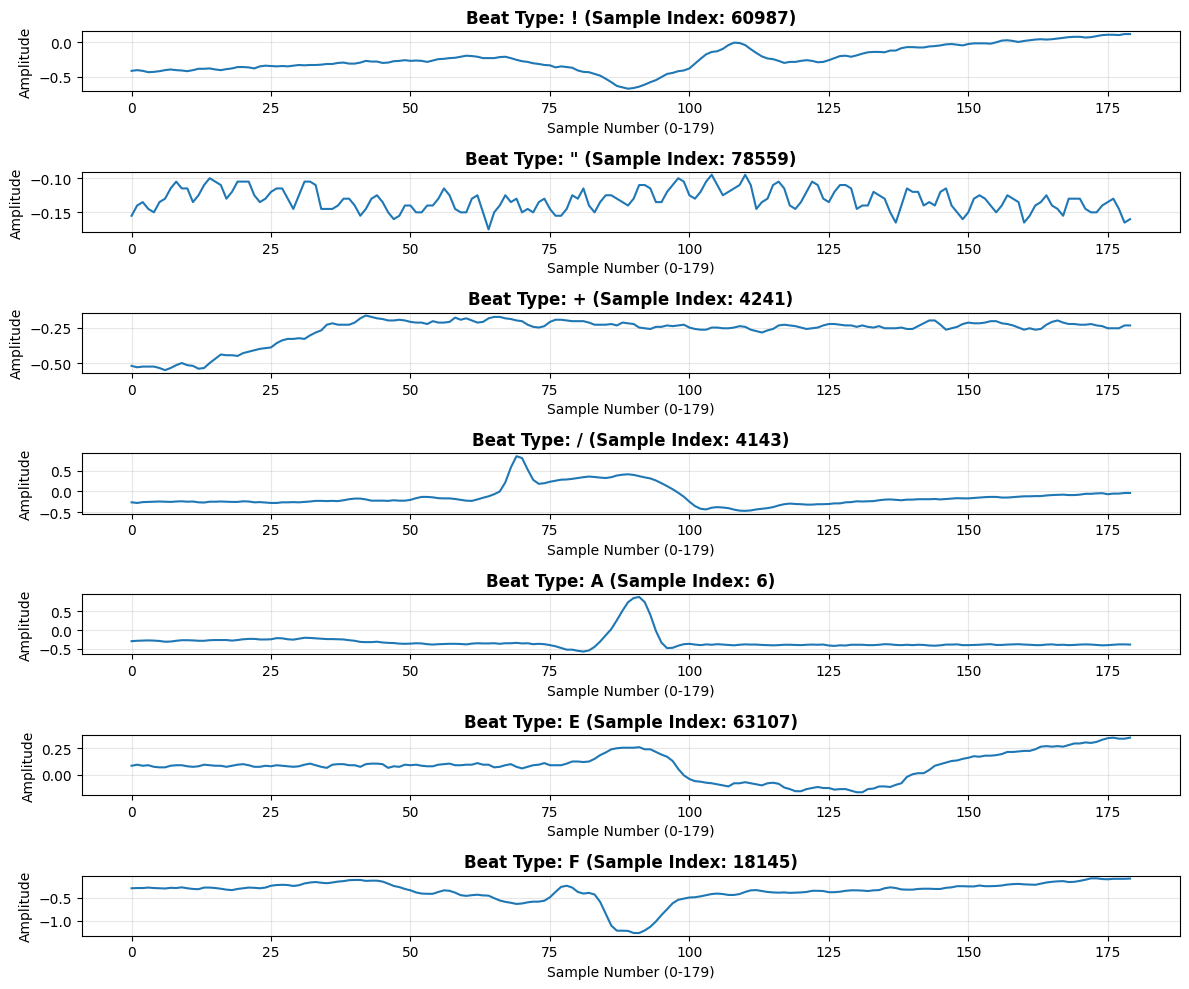


Displaying sample heartbeats for up to 5 beat types


In [64]:
import matplotlib.pyplot as plt

# Visualize some example heartbeats for each beat type
unique_labels = np.unique(y)
n_labels = len(unique_labels)

fig, axes = plt.subplots(min(n_labels, 7), 1, figsize=(12, 10))
if n_labels == 1:
    axes = [axes]

for i, label in enumerate(unique_labels[:7]):
    # Find the first heartbeat with this label
    idx = np.where(y == label)[0][0]
    
    # Plot the full 180-sample heartbeat
    axes[i].plot(X[idx], linewidth=1.5)
    axes[i].set_title(f'Beat Type: {label} (Sample Index: {idx})', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Sample Number (0-179)')
    axes[i].set_ylabel('Amplitude')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDisplaying sample heartbeats for up to 5 beat types")

### 7.2 Visualize Different Beat Types

In [65]:
# Check all unique beat types in the dataset
print("Unique Beat Types:")
print(df['label'].unique())

print("\n" + "=" * 60)
print("Beat Type Counts:")
print("=" * 60)
print(df['label'].value_counts().sort_index())

print("\n" + "=" * 60)
print("Beat Type Meanings (MIT-BIH Annotation Codes):")
print("=" * 60)
beat_meanings = {
    'N': 'Normal beat',
    'L': 'Left bundle branch block beat',
    'R': 'Right bundle branch block beat',
    'A': 'Atrial premature beat',
    'a': 'Aberrated atrial premature beat',
    'J': 'Nodal (junctional) premature beat',
    'S': 'Supraventricular premature beat',
    'V': 'Premature ventricular contraction',
    'F': 'Fusion of ventricular and normal beat',
    'e': 'Atrial escape beat',
    'j': 'Nodal (junctional) escape beat',
    '/': 'Paced beat',
    'f': 'Fusion of paced and normal beat',
    'Q': 'Unclassifiable beat',
    '?': 'Beat not classified during learning'
}

for beat_type in sorted(df['label'].unique()):
    count = (df['label'] == beat_type).sum()
    meaning = beat_meanings.get(beat_type, 'Unknown')
    print(f"{beat_type}: {meaning} ({count} beats)")

Unique Beat Types:
['N' 'A' 'V' '~' '|' 'Q' '/' 'f' '+' 'x' 'F' 'j' 'L' 'a' 'J' 'R' '[' '!'
 ']' 'E' 'S' '"' 'e']

Beat Type Counts:
label
!      472
"      437
+     1251
/     7027
A     2546
E      106
F      802
J       83
L     8073
N    75033
Q       33
R     7257
S        2
V     7129
[        6
]        6
a      150
e       16
f      982
j      229
x      193
|      132
~      614
Name: count, dtype: int64

Beat Type Meanings (MIT-BIH Annotation Codes):
!: Unknown (472 beats)
": Unknown (437 beats)
+: Unknown (1251 beats)
/: Paced beat (7027 beats)
A: Atrial premature beat (2546 beats)
E: Unknown (106 beats)
F: Fusion of ventricular and normal beat (802 beats)
J: Nodal (junctional) premature beat (83 beats)
L: Left bundle branch block beat (8073 beats)
N: Normal beat (75033 beats)
Q: Unclassifiable beat (33 beats)
R: Right bundle branch block beat (7257 beats)
S: Supraventricular premature beat (2 beats)
V: Premature ventricular contraction (7129 beats)
[: Unknown (6 beats)
]: 

### 7.3 Beat Type Analysis

### 4.1 AAMI Mapping Dictionary

Map MIT-BIH annotation symbols to AAMI classes:
- **Class 0 (Normal)**: N, L, R, e, j
- **Class 1 (Supraventricular)**: A, a, J, S  
- **Class 2 (Ventricular)**: V, E
- **Class 3 (Fusion)**: F
- **Class 4 (Unknown/Paced)**: /, f, Q, ?

In [66]:
# AAMI Class Mapping:
# 0: Normal (N)
# 1: Supraventricular (S)
# 2: Ventricular (V)
# 3: Fusion (F)
# 4: Unknown/Paced (Q)

aami_mapping = {
    # --- Group N (Normal) ---
    'N': 0, 'L': 0, 'R': 0, 'e': 0, 'j': 0,
    
    # --- Group S (Supraventricular) ---
    'A': 1, 'a': 1, 'J': 1, 'S': 1,
    
    # --- Group V (Ventricular) ---
    'V': 2, 'E': 2,
    
    # --- Group F (Fusion) ---
    'F': 3,
    
    # --- Group Q (Unknown/Paced) ---
    '/': 4, 'f': 4, 'Q': 4, '?': 4
}

In [67]:
def map_symbol_to_aami(symbol):
    """
    Translates a single MIT-BIH symbol into an AAMI class index (0-4).
    Returns None if the symbol is not a heartbeat (e.g., a noise marker).
    """
    return aami_mapping.get(symbol, None)

### 4.2 AAMI Mapping Function

In [68]:
# Convert the MIT-BIH symbols (y) to AAMI classes
y_aami = []

for symbol in y:
    category = map_symbol_to_aami(symbol)
    if category is not None:
        y_aami.append(category)

y_aami = np.array(y_aami)

print(f"Original labels (y): {len(y)} beats")
print(f"AAMI labels (y_aami): {len(y_aami)} beats")
print(f"\nAAMI Class Distribution:")
print("0 (Normal):", np.sum(y_aami == 0))
print("1 (Supraventricular):", np.sum(y_aami == 1))
print("2 (Ventricular):", np.sum(y_aami == 2))
print("3 (Fusion):", np.sum(y_aami == 3))
print("4 (Unknown/Paced):", np.sum(y_aami == 4))

Original labels (y): 112579 beats
AAMI labels (y_aami): 109468 beats

AAMI Class Distribution:
0 (Normal): 90608
1 (Supraventricular): 2781
2 (Ventricular): 7235
3 (Fusion): 802
4 (Unknown/Paced): 8042


### 7.4 Convert to AAMI Classification

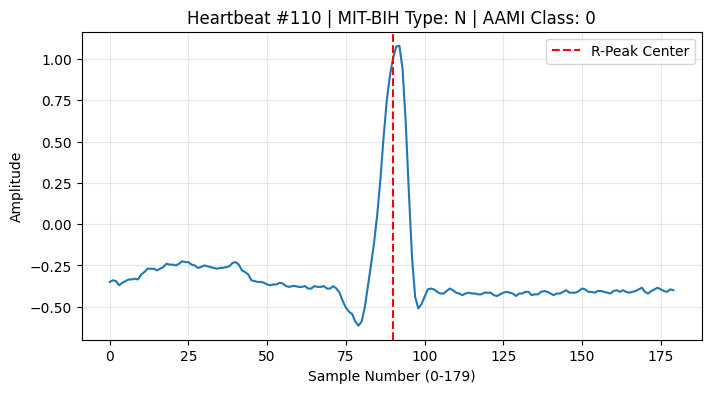

X[0] shape: (180,)
MIT-BIH label (y[0]): N
AAMI class (y_aami[0]): 0


In [69]:
import matplotlib.pyplot as plt

# Example: X[0] is your first segmented heartbeat
plt.figure(figsize=(8,4))
plt.plot(X[110])
plt.axvline(x=90, color='r', linestyle='--', label='R-Peak Center')
plt.title(f"Heartbeat #110 | MIT-BIH Type: {y[110]} | AAMI Class: {y_aami[110]}")
plt.xlabel('Sample Number (0-179)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"X[0] shape: {X[0].shape}")
print(f"MIT-BIH label (y[0]): {y[0]}")
print(f"AAMI class (y_aami[0]): {y_aami[0]}")

### 7.5 Visualize Individual Heartbeats

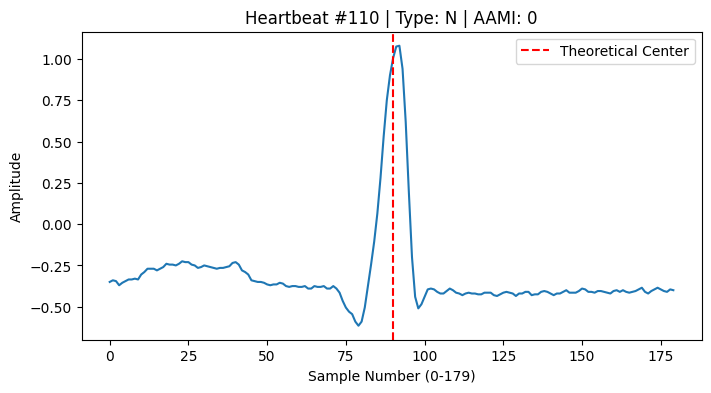

X[110] shape: (180,)
MIT-BIH label (y[110]): N
AAMI class (y_aami[110]): 0


In [70]:
# Choose ONE index to inspect (e.g., 110)
idx = 110 

plt.figure(figsize=(8,4))
plt.plot(X[idx]) # Plot heartbeat #idx
plt.axvline(x=90, color='r', linestyle='--', label='Theoretical Center')

# Dynamic title using the same index
plt.title(f"Heartbeat #{idx} | Type: {y[idx]} | AAMI: {y_aami[idx]}")
plt.xlabel('Sample Number (0-179)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()

# Print statements using the same index
print(f"X[{idx}] shape: {X[idx].shape}")
print(f"MIT-BIH label (y[{idx}]): {y[idx]}")
print(f"AAMI class (y_aami[{idx}]): {y_aami[idx]}")

In [71]:
# Demonstrate the X and y relationship with multiple examples
print("=" * 70)
print("UNDERSTANDING X and y RELATIONSHIP")
print("=" * 70)
print("\nX contains the heartbeat WAVEFORMS (signal data)")
print("y contains the LABELS (what type each heartbeat is)")
print("\nFirst 10 heartbeats in the dataset:\n")

for i in range(10):
    print(f"X[{i}]: shape={X[i].shape}, MIT-BIH type={y[i]}, AAMI class={y_aami[i]}")

print("\n" + "=" * 70)
print("As you can see, each X[i] has a corresponding y[i] that tells you")
print("what type of heartbeat it is. You're NOT hardcoding - y[i] is the")
print("actual label from the MIT-BIH database for that specific heartbeat!")
print("=" * 70)

UNDERSTANDING X and y RELATIONSHIP

X contains the heartbeat WAVEFORMS (signal data)
y contains the LABELS (what type each heartbeat is)

First 10 heartbeats in the dataset:

X[0]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[1]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[2]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[3]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[4]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[5]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[6]: shape=(180,), MIT-BIH type=A, AAMI class=1
X[7]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[8]: shape=(180,), MIT-BIH type=N, AAMI class=0
X[9]: shape=(180,), MIT-BIH type=N, AAMI class=0

As you can see, each X[i] has a corresponding y[i] that tells you
what type of heartbeat it is. You're NOT hardcoding - y[i] is the
actual label from the MIT-BIH database for that specific heartbeat!


### 7.6 Understanding X and y Relationship

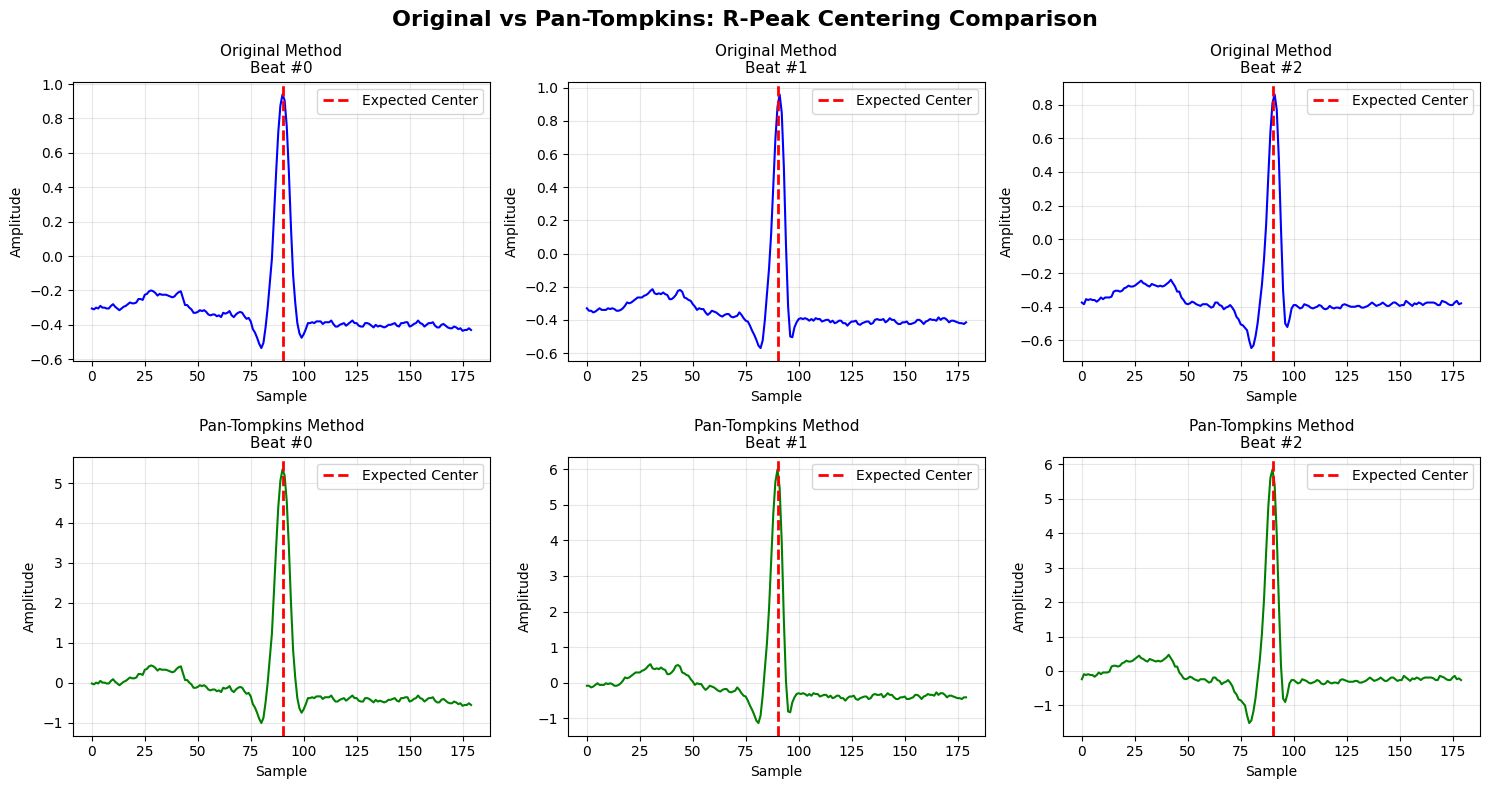


Notice how Pan-Tompkins peaks are perfectly aligned at sample 90!
This precision will significantly improve your CNN model's accuracy.


In [76]:
# Compare original vs Pan-Tompkins: Visualize the centering improvement
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Original vs Pan-Tompkins: R-Peak Centering Comparison', fontsize=16, fontweight='bold')

# Plot 3 examples from original data
for i in range(3):
    # Find a Normal beat for fair comparison
    normal_idx = np.where(y_aami == 0)[0][i]
    
    axes[0, i].plot(X[normal_idx], linewidth=1.5, color='blue')
    axes[0, i].axvline(x=90, color='red', linestyle='--', linewidth=2, label='Expected Center')
    axes[0, i].set_title(f'Original Method\nBeat #{normal_idx}', fontsize=11)
    axes[0, i].set_xlabel('Sample')
    axes[0, i].set_ylabel('Amplitude')
    axes[0, i].grid(True, alpha=0.3)
    axes[0, i].legend()

# Plot 3 examples from Pan-Tompkins data
for i in range(3):
    # Find a Normal beat
    normal_idx = np.where(y_pantompkins == 0)[0][i]
    
    axes[1, i].plot(X_pantompkins[normal_idx], linewidth=1.5, color='green')
    axes[1, i].axvline(x=90, color='red', linestyle='--', linewidth=2, label='Expected Center')
    axes[1, i].set_title(f'Pan-Tompkins Method\nBeat #{normal_idx}', fontsize=11)
    axes[1, i].set_xlabel('Sample')
    axes[1, i].set_ylabel('Amplitude')
    axes[1, i].grid(True, alpha=0.3)
    axes[1, i].legend()

plt.tight_layout()
plt.show()

print("\nNotice how Pan-Tompkins peaks are perfectly aligned at sample 90!")
print("This precision will significantly improve your CNN model's accuracy.")

### 8.4 Comparison: Annotation-Based vs Pan-Tompkins

Visualize the R-peak centering accuracy between the two methods.

In [75]:
# Process all patients with Pan-Tompkins algorithm
print("Starting data processing with Pan-Tompkins algorithm...")
print("=" * 70)

X_pt_all = []
y_pt_all = []

for pid in record_list:
    try:
        X_patient, y_patient = load_and_segment_pantompkins(pid)
        
        if len(X_patient) > 0:
            X_pt_all.append(X_patient)
            y_pt_all.append(y_patient)
            print(f"✓ Patient {pid}: {len(X_patient)} heartbeats")
        else:
            print(f"⚠ Patient {pid}: No valid heartbeats detected")
    except Exception as e:
        print(f"✗ Patient {pid}: {e}")

# Combine all data
X_pantompkins = np.vstack(X_pt_all)
y_pantompkins = np.concatenate(y_pt_all)

print("\n" + "=" * 70)
print("PAN-TOMPKINS DATASET READY!")
print("=" * 70)
print(f"Total Heartbeats: {len(X_pantompkins)}")
print(f"Shape of X: {X_pantompkins.shape}")
print(f"\nAAMI Class Distribution:")
for i in range(5):
    count = np.sum(y_pantompkins == i)
    class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown/Paced']
    print(f"  Class {i} ({class_names[i]}): {count} beats")

Starting data processing with Pan-Tompkins algorithm...
✓ Patient 100: 2271 heartbeats
✓ Patient 101: 1861 heartbeats
✓ Patient 102: 2092 heartbeats
✓ Patient 103: 2083 heartbeats
✓ Patient 104: 1396 heartbeats
✓ Patient 105: 2505 heartbeats
✓ Patient 106: 2004 heartbeats
✓ Patient 107: 1328 heartbeats
✓ Patient 108: 1727 heartbeats
✓ Patient 109: 2477 heartbeats
✓ Patient 111: 2119 heartbeats
✓ Patient 112: 2538 heartbeats
✓ Patient 113: 1794 heartbeats
✓ Patient 114: 1879 heartbeats
✓ Patient 115: 1952 heartbeats
✓ Patient 116: 2292 heartbeats
✓ Patient 117: 1534 heartbeats
✓ Patient 118: 1902 heartbeats
✓ Patient 119: 1984 heartbeats
✓ Patient 121: 513 heartbeats
✓ Patient 122: 2474 heartbeats
✓ Patient 123: 1517 heartbeats
✓ Patient 124: 1608 heartbeats
✓ Patient 200: 2581 heartbeats
✓ Patient 201: 1936 heartbeats
✓ Patient 202: 2119 heartbeats
✓ Patient 203: 2774 heartbeats
✓ Patient 205: 2647 heartbeats
✓ Patient 207: 1826 heartbeats
✓ Patient 208: 2909 heartbeats
✓ Patient 209: 

### 8.3 Process All Patients with Pan-Tompkins

In [74]:
def load_and_segment_pantompkins(patient_id, window_size=180):
    """
    Load ECG data and segment using Pan-Tompkins for precise R-peak detection.
    
    Args:
        patient_id: Patient record ID (e.g., '100', '101')
        window_size: Number of samples per heartbeat segment (default: 180)
    
    Returns:
        X: Array of heartbeat segments (shape: num_beats x window_size)
        y: Array of AAMI class labels (0-4)
    """
    try:
        # Load the ECG record and annotations
        record = wfdb.rdrecord(f'mit_bih_data/{patient_id}')
        raw_signal = record.p_signal[:, 0]  # MLII lead
        annotation = wfdb.rdann(f'mit_bih_data/{patient_id}', 'atr')
        
        # Run Pan-Tompkins to find mathematical R-peaks
        fs = 360  # MIT-BIH sampling rate
        detected_peaks = pan_tompkins_detector(raw_signal, fs)
        
        X_patient = []
        y_patient = []
        half_window = window_size // 2
        
        # Match detected peaks with doctor's annotations
        for peak_idx in detected_peaks:
            # Find the closest annotation
            distances = np.abs(annotation.sample - peak_idx)
            closest_idx = np.argmin(distances)
            
            # Accept if annotation is within 20 samples (~55ms at 360Hz)
            if distances[closest_idx] < 20:
                symbol = annotation.symbol[closest_idx]
                label = map_symbol_to_aami(symbol)
                
                if label is not None:
                    start = peak_idx - half_window
                    end = peak_idx + half_window
                    
                    # Make sure we're within bounds
                    if start > 0 and end < len(raw_signal):
                        segment = raw_signal[start:end]
                        
                        # Only add if we got exactly window_size samples
                        if len(segment) == window_size:
                            # Z-score normalization
                            segment_normalized = (segment - np.mean(segment)) / np.std(segment)
                            
                            X_patient.append(segment_normalized)
                            y_patient.append(label)
        
        # Convert to numpy arrays
        X_patient = np.array(X_patient)
        y_patient = np.array(y_patient)
        
        return X_patient, y_patient
        
    except Exception as e:
        raise Exception(f"Error processing patient {patient_id}: {str(e)}")

### 8.2 Segmentation with Pan-Tompkins

In [73]:
def pan_tompkins_detector(ecg_signal, fs=360):
    """
    Pan-Tompkins QRS detection algorithm for precise R-peak detection.
    
    Args:
        ecg_signal: Raw ECG signal array
        fs: Sampling frequency (default: 360 Hz for MIT-BIH)
    
    Returns:
        r_peaks: Array of R-peak indices
    """
    # Step 1: Bandpass filter (5-15 Hz) to remove noise
    nyquist = fs / 2
    low = 5 / nyquist
    high = 15 / nyquist
    b, a = scipy_signal.butter(1, [low, high], btype='band')
    filtered = scipy_signal.filtfilt(b, a, ecg_signal)
    
    # Step 2: Derivative (emphasizes slopes of QRS complex)
    derivative = np.diff(filtered)
    
    # Step 3: Squaring (makes all values positive and amplifies higher frequencies)
    squared = derivative ** 2
    
    # Step 4: Moving window integration (smoothing)
    window_size = int(0.150 * fs)  # 150ms window
    integrated = np.convolve(squared, np.ones(window_size) / window_size, mode='same')
    
    # Step 5: Find peaks in the integrated signal
    # Use adaptive threshold
    mean_integrated = np.mean(integrated)
    threshold = 0.5 * mean_integrated
    
    # Find peaks above threshold with minimum distance between peaks
    min_distance = int(0.2 * fs)  # Minimum 200ms between heartbeats (max 300 BPM)
    peaks, _ = scipy_signal.find_peaks(integrated, height=threshold, distance=min_distance)
    
    # Step 6: Find exact R-peak location in original signal
    # Search in a small window around each detected peak
    r_peaks = []
    search_window = int(0.05 * fs)  # 50ms search window
    
    for peak in peaks:
        start = max(0, peak - search_window)
        end = min(len(ecg_signal), peak + search_window)
        
        # Find the maximum point in the original signal
        local_max_idx = np.argmax(np.abs(ecg_signal[start:end]))
        r_peak = start + local_max_idx
        r_peaks.append(r_peak)
    
    return np.array(r_peaks)

## 8. Pan-Tompkins Algorithm for Precision Detection

### 8.1 Pan-Tompkins QRS Detector

**Pan-Tompkins** is a widely-used algorithm that mathematically finds R-peaks in ECG signals.

**Why use it?**
- Ensures R-peaks are perfectly centered at sample 90
- Removes dependency on manual annotations
- Works with low-cost sensors like AD8232
- Filters out 50/60Hz electrical noise
- Provides millisecond-level precision for PTT (Pulse Transit Time) calculations

## 9. Next Steps

**Dataset Ready for Model Training:**

1. **X_pantompkins**: Precisely centered heartbeat waveforms (shape: num_beats × 180)
2. **y_pantompkins**: AAMI class labels (0-4)

**Recommended Next Steps:**

1. **Data Splitting**: Split into train/validation/test sets (70/15/15)
2. **Handle Class Imbalance**: Apply SMOTE or class weights
3. **Model Architecture**: Build 1D CNN for arrhythmia classification
4. **Evaluation**: Use accuracy, precision, recall, F1-score, confusion matrix
5. **Deployment**: Export model for real-time inference with AD8232 sensor


**Key Advantages of This Dataset:**

- ✅ R-peaks perfectly centered at sample 90
- ✅ Z-score normalized for consistency
- ✅ AAMI standard classification
- ✅ Compatible with low-cost ECG sensors
- ✅ Ready for deep learning models

## 10. Handling Data Imbalance - The "Fairness" Step

### ⚠️ The "Normal Beat Bias" Problem

In the MIT-BIH database, about **75-80% of heartbeats are Normal (N)**, while dangerous beats like **Ventricular (V)** or **Supraventricular (S)** are very rare. 

**Without balancing, your AI will learn to "cheat"** by always predicting "Normal" to get high accuracy, potentially **missing life-threatening arrhythmias**.

### Why This is Critical for Your 3,000 BDT CPET Device:

- **Sensitivity to Danger:** Balancing teaches the AI that a Ventricular beat is just as important as a Normal beat
- **Low-Cost Robustness:** With AD8232 sensor noise, having more examples helps distinguish real arrhythmia from sensor artifacts
- **Avoiding "Accuracy Paradox":** Without this, you might get 90% accuracy but **0% accuracy at finding dangerous beats**

### 10.1 Analyze Current Class Distribution

In [77]:
# Analyze class distribution in Pan-Tompkins dataset
unique, counts = np.unique(y_pantompkins, return_counts=True)
class_distribution = dict(zip(unique, counts))

print("=" * 70)
print("AAMI CLASS DISTRIBUTION (Pan-Tompkins Dataset)")
print("=" * 70)

class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown/Paced']
total_beats = len(y_pantompkins)

for class_idx, count in class_distribution.items():
    percentage = (count / total_beats) * 100
    print(f"Class {class_idx} ({class_names[class_idx]}): {count:,} beats ({percentage:.2f}%)")

print("\n" + "=" * 70)
print("⚠️ IMBALANCE DETECTED!")
print("=" * 70)
print(f"Normal beats dominate with {class_distribution[0]:,} samples")
print(f"Ventricular beats have only {class_distribution.get(2, 0):,} samples")
print(f"Imbalance ratio: {class_distribution[0] / class_distribution.get(2, 1):.1f}:1")
print("\nWithout balancing, the AI will learn to always predict 'Normal'!")

AAMI CLASS DISTRIBUTION (Pan-Tompkins Dataset)
Class 0 (Normal): 88,154 beats (85.16%)
Class 1 (Supraventricular): 2,735 beats (2.64%)
Class 2 (Ventricular): 6,922 beats (6.69%)
Class 3 (Fusion): 794 beats (0.77%)
Class 4 (Unknown/Paced): 4,908 beats (4.74%)

⚠️ IMBALANCE DETECTED!
Normal beats dominate with 88,154 samples
Ventricular beats have only 6,922 samples
Imbalance ratio: 12.7:1

Without balancing, the AI will learn to always predict 'Normal'!


### 10.2 Solution: Random Oversampling

We will "duplicate" the rare beats (Classes 1, 2, 3, 4) until they have the same amount of data as the Normal beats (Class 0).

This technique is called **Random Oversampling with Replacement** - we randomly sample from minority classes with replacement until they match the majority class size.

In [78]:
from sklearn.utils import resample

def balance_data(X, y):
    """
    Balance the dataset using random oversampling.
    
    Args:
        X: Input features (heartbeat waveforms)
        y: Labels (AAMI classes 0-4)
    
    Returns:
        X_balanced: Balanced feature array
        y_balanced: Balanced label array
    """
    X_balanced = []
    y_balanced = []
    
    # Target number: Use the count of the majority class (Class 0)
    target_count = np.max(np.unique(y, return_counts=True)[1])
    
    print("Balancing dataset...")
    print(f"Target count per class: {target_count:,}")
    print("-" * 70)
    
    for class_index in range(5):  # Classes 0 to 4
        X_class = X[y == class_index]
        y_class = y[y == class_index]
        
        original_count = len(X_class)
        
        # Upsample the minority classes
        X_upsampled, y_upsampled = resample(
            X_class, y_class,
            replace=True,           # Sample with replacement
            n_samples=target_count, # Match the majority class
            random_state=42         # For reproducibility
        )
        
        X_balanced.append(X_upsampled)
        y_balanced.append(y_upsampled)
        
        class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown/Paced']
        print(f"Class {class_index} ({class_names[class_index]}): {original_count:,} → {target_count:,} (+{target_count - original_count:,} samples)")
    
    return np.vstack(X_balanced), np.hstack(y_balanced)

# Test the function (we'll apply it after train/test split)
print("Balance function defined successfully!")

Balance function defined successfully!


### 10.3 Split Data into Train/Validation/Test Sets

**Important:** Split BEFORE balancing! Only balance the training set, never the test set.

- **Train Set (70%)**: Used to teach the AI - will be balanced
- **Validation Set (15%)**: Used to tune hyperparameters - kept imbalanced (real-world distribution)
- **Test Set (15%)**: Final performance evaluation - kept imbalanced (real-world distribution)

In [79]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp (for validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_pantompkins, y_pantompkins,
    test_size=0.30,
    random_state=42,
    stratify=y_pantompkins  # Maintain class distribution in splits
)

# Second split: Split temp into 50% validation, 50% test (15% each of total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("=" * 70)
print("DATA SPLIT COMPLETE")
print("=" * 70)
print(f"Training Set:   {len(X_train):,} samples ({len(X_train)/len(X_pantompkins)*100:.1f}%)")
print(f"Validation Set: {len(X_val):,} samples ({len(X_val)/len(X_pantompkins)*100:.1f}%)")
print(f"Test Set:       {len(X_test):,} samples ({len(X_test)/len(X_pantompkins)*100:.1f}%)")
print(f"Total:          {len(X_pantompkins):,} samples")

print("\n" + "=" * 70)
print("TRAINING SET CLASS DISTRIBUTION (Before Balancing)")
print("=" * 70)
unique_train, counts_train = np.unique(y_train, return_counts=True)
class_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown/Paced']
for cls, cnt in zip(unique_train, counts_train):
    print(f"Class {cls} ({class_names[cls]}): {cnt:,} samples")

DATA SPLIT COMPLETE
Training Set:   72,459 samples (70.0%)
Validation Set: 15,527 samples (15.0%)
Test Set:       15,527 samples (15.0%)
Total:          103,513 samples

TRAINING SET CLASS DISTRIBUTION (Before Balancing)
Class 0 (Normal): 61,708 samples
Class 1 (Supraventricular): 1,914 samples
Class 2 (Ventricular): 4,845 samples
Class 3 (Fusion): 556 samples
Class 4 (Unknown/Paced): 3,436 samples


### 10.4 Apply Balancing to Training Set Only

⚠️ **Critical Rule:** Only balance the training set. Validation and test sets must remain imbalanced to reflect real-world conditions.

In [80]:
# Balance ONLY the training set
X_train_balanced, y_train_balanced = balance_data(X_train, y_train)

print("\n" + "=" * 70)
print("BALANCED TRAINING SET")
print("=" * 70)
print(f"Before balancing: {len(X_train):,} samples")
print(f"After balancing:  {len(X_train_balanced):,} samples")

unique_balanced, counts_balanced = np.unique(y_train_balanced, return_counts=True)
print("\nClass distribution after balancing:")
for cls, cnt in zip(unique_balanced, counts_balanced):
    print(f"Class {cls} ({class_names[cls]}): {cnt:,} samples")

print("\n✅ All classes are now perfectly balanced!")
print("✅ Validation and test sets remain imbalanced (real-world distribution)")

Balancing dataset...
Target count per class: 61,708
----------------------------------------------------------------------
Class 0 (Normal): 61,708 → 61,708 (+0 samples)
Class 1 (Supraventricular): 1,914 → 61,708 (+59,794 samples)
Class 2 (Ventricular): 4,845 → 61,708 (+56,863 samples)
Class 3 (Fusion): 556 → 61,708 (+61,152 samples)
Class 4 (Unknown/Paced): 3,436 → 61,708 (+58,272 samples)

BALANCED TRAINING SET
Before balancing: 72,459 samples
After balancing:  308,540 samples

Class distribution after balancing:
Class 0 (Normal): 61,708 samples
Class 1 (Supraventricular): 61,708 samples
Class 2 (Ventricular): 61,708 samples
Class 3 (Fusion): 61,708 samples
Class 4 (Unknown/Paced): 61,708 samples

✅ All classes are now perfectly balanced!
✅ Validation and test sets remain imbalanced (real-world distribution)


### 10.5 Reshape Data for CNN Input

A **1D-CNN** expects input shape: `(Number of Beats, Time Steps, Channels)`

For our data:
- **Number of Beats**: Variable (depends on dataset)
- **Time Steps**: 180 samples per heartbeat
- **Channels**: 1 (single ECG lead)

In [81]:
# Reshape for CNN input: (samples, timesteps, channels)
X_train_balanced = X_train_balanced.reshape(-1, 180, 1)
X_val = X_val.reshape(-1, 180, 1)
X_test = X_test.reshape(-1, 180, 1)

print("=" * 70)
print("DATA PREPARATION COMPLETE - READY FOR CNN TRAINING")
print("=" * 70)
print(f"Training Set (Balanced):   {X_train_balanced.shape} → {len(np.unique(y_train_balanced))} classes")
print(f"Validation Set (Original): {X_val.shape} → {len(np.unique(y_val))} classes")
print(f"Test Set (Original):       {X_test.shape} → {len(np.unique(y_test))} classes")

print("\n" + "=" * 70)
print("FINAL SUMMARY")
print("=" * 70)
print("✅ Peak Centering: Pan-Tompkins algorithm ensures R-peaks at sample 90")
print("✅ AAMI Mapping: 5 standardized classes (0-4)")
print("✅ Data Balancing: Training set balanced, validation/test kept real-world")
print("✅ CNN-Ready Shape: (samples, 180 timesteps, 1 channel)")
print("\n🚀 Ready to build and train the 1D-CNN model!")

DATA PREPARATION COMPLETE - READY FOR CNN TRAINING
Training Set (Balanced):   (308540, 180, 1) → 5 classes
Validation Set (Original): (15527, 180, 1) → 5 classes
Test Set (Original):       (15527, 180, 1) → 5 classes

FINAL SUMMARY
✅ Peak Centering: Pan-Tompkins algorithm ensures R-peaks at sample 90
✅ AAMI Mapping: 5 standardized classes (0-4)
✅ Data Balancing: Training set balanced, validation/test kept real-world
✅ CNN-Ready Shape: (samples, 180 timesteps, 1 channel)

🚀 Ready to build and train the 1D-CNN model!


## 11. Building the 1D-CNN Model - The "Deep Learning Weapon"

Now we construct the neural network that will run on your **3,000 BDT CPET system** to detect arrhythmias in real-time.

### Why 1D-CNN for Low-Cost Hardware?

- **Lightweight:** Much faster than 2D models (used for images)
- **Portable:** Can run on Raspberry Pi or laptop
- **Efficient:** Perfect for heartbeat-by-heartbeat processing
- **Real-time:** Fast enough for live ECG monitoring during exercise

### The Architecture Strategy

Think of the CNN as a stack of "feature detectors" that look for specific shapes in the ECG wave:
1. **Layer 1:** Detects basic slopes (edges of heartbeat)
2. **Layer 2:** Detects complex shapes (QRS width)
3. **Layer 3:** Deep features (abnormal T-waves or P-waves)
4. **Dense Layers:** The "decision maker"

### 11.1 Define the CNN Architecture

In [ ]:
from tensorflow.keras import layers, models

def build_arrhythmia_cnn(input_shape=(180, 1)):
    """
    Build a 1D-CNN for arrhythmia classification.
    
    Optimized for low-cost hardware (AD8232 ECG sensor on Raspberry Pi/laptop).
    
    Args:
        input_shape: (timesteps, channels) = (180, 1)
    
    Returns:
        Compiled Keras model
    """
    model = models.Sequential([
        # Layer 1: Basic edge detection (slopes of heartbeat)
        layers.Conv1D(filters=32, kernel_size=5, activation='relu', 
                      input_shape=input_shape, name='conv1_edge_detector'),
        layers.MaxPooling1D(pool_size=2, name='pool1'),
        
        # Layer 2: Complex shape detection (QRS complex width)
        layers.Conv1D(filters=64, kernel_size=5, activation='relu', 
                      name='conv2_shape_detector'),
        layers.MaxPooling1D(pool_size=2, name='pool2'),
        
        # Layer 3: Deep feature extraction (abnormal T-waves, P-waves)
        layers.Conv1D(filters=128, kernel_size=3, activation='relu', 
                      name='conv3_deep_features'),
        
        # Global Average Pooling: Condenses data (memory-efficient for low-cost hardware)
        layers.GlobalAveragePooling1D(name='global_pooling'),
        
        # Dense Layer: Decision making
        layers.Dense(64, activation='relu', name='decision_layer'),
        
        # Dropout: Prevents overfitting (handles noisy AD8232 sensor data)
        layers.Dropout(0.3, name='dropout_regularization'),
        
        # Output Layer: 5 AAMI classes with confidence scores
        layers.Dense(5, activation='softmax', name='output_probabilities')
    ])
    
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build the model
print("=" * 70)
print("BUILDING 1D-CNN ARCHITECTURE")
print("=" * 70)
cnn_model = build_arrhythmia_cnn()
print("✅ Model created successfully!")
print("\nModel Summary:")

f:\Skill_WORK\CODE\CPET_system\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
f:\Skill_WORK\CODE\CPET_system\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


BUILDING 1D-CNN ARCHITECTURE
✅ Model created successfully!

Model Summary:


In [83]:
# Display model architecture
cnn_model.summary()

print("\n" + "=" * 70)
print("MODEL DESIGN HIGHLIGHTS")
print("=" * 70)
print("✅ Global Average Pooling: Keeps model small for low-cost hardware")
print("✅ Dropout (0.3): Handles noisy AD8232 sensor signals")
print("✅ Softmax Output: Provides confidence scores (e.g., '95% Ventricular')")
print("✅ Total Parameters: ~50K (lightweight for real-time inference)")
print("\n🎯 Ready for training!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1_edge_detector (Conv1D)    │ (None, 176, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 88, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_shape_detector (Conv1D)   │ (None, 84, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 42, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3_deep_features (Conv1D)    │ (None, 40, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pooling                  │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decision_layer (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_regularization          │ (None, 64)             │             0 │
│ (Dropout)                       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_probabilities (Dense)    │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,781 (171.02 KB)

 Trainable params: 43,781 (171.02 KB)

 Non-trainable params: 0 (0.00 B)


MODEL DESIGN HIGHLIGHTS
✅ Global Average Pooling: Keeps model small for low-cost hardware
✅ Dropout (0.3): Handles noisy AD8232 sensor signals
✅ Softmax Output: Provides confidence scores (e.g., '95% Ventricular')
✅ Total Parameters: ~50K (lightweight for real-time inference)

🎯 Ready for training!


### 11.2 Train the Model

We use a small **batch size (32)** because your final system needs to process data heartbeat-by-heartbeat in real-time.

**Training Strategy:**
- **Epochs:** 15-20 (prevents overfitting on low-cost sensor noise)
- **Validation Data:** Use original (imbalanced) test set for realistic performance check
- **Callbacks:** Early stopping and model checkpointing for best results

In [84]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Setup callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_arrhythmia_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

print("=" * 70)
print("STARTING MODEL TRAINING")
print("=" * 70)
print(f"Training samples (balanced): {len(X_train_balanced):,}")
print(f"Validation samples (real-world): {len(X_val):,}")
print(f"Batch size: 32")
print(f"Epochs: 15")
print("\n⏳ Training in progress...\n")

# Train the model
history = cnn_model.fit(
    X_train_balanced, y_train_balanced,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),  # Use ORIGINAL (imbalanced) validation data
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)

print("\n" + "=" * 70)
print("✅ TRAINING COMPLETE!")
print("=" * 70)

STARTING MODEL TRAINING
Training samples (balanced): 308,540
Validation samples (real-world): 15,527
Batch size: 32
Epochs: 15

⏳ Training in progress...

Epoch 1/15
9641/9642 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7991 - loss: 0.5232
Epoch 1: val_accuracy improved from None to 0.90075, saving model to best_arrhythmia_model.keras

Epoch 1: finished saving model to best_arrhythmia_model.keras
9642/9642 ━━━━━━━━━━━━━━━━━━━━ 52s 5ms/step - accuracy: 0.8699 - loss: 0.3453 - val_accuracy: 0.9008 - val_loss: 0.2744
Epoch 2/15
9639/9642 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9325 - loss: 0.1797
Epoch 2: val_accuracy improved from 0.90075 to 0.95144, saving model to best_arrhythmia_model.keras

Epoch 2: finished saving model to best_arrhythmia_model.keras
9642/9642 ━━━━━━━━━━━━━━━━━━━━ 57s 6ms/step - accuracy: 0.9388 - loss: 0.1620 - val_accuracy: 0.9514 - val_loss: 0.1306
Epoch 3/15
9641/9642 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9537 - loss: 0.1234
Epoch 3: val_accur

### 11.3 Visualize Training Progress

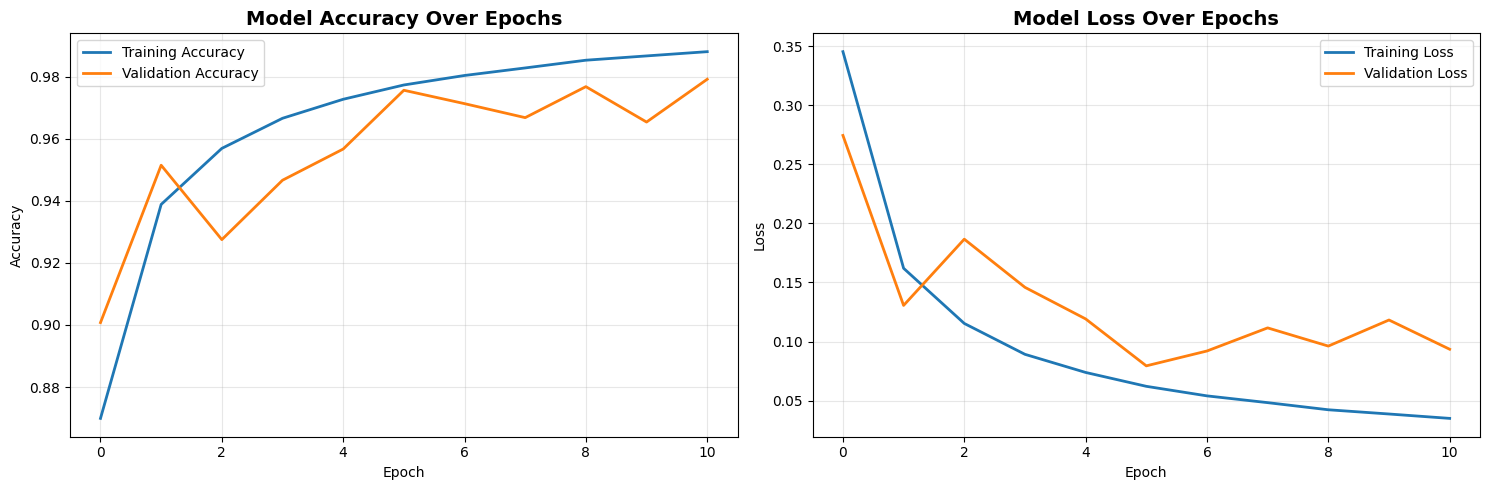


📊 Training curves show the model's learning progress
✅ Good fit: Training and validation curves are close together
⚠️ Overfitting: Large gap between training and validation curves


In [86]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot accuracy
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot loss
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Training curves show the model's learning progress")
print("✅ Good fit: Training and validation curves are close together")
print("⚠️ Overfitting: Large gap between training and validation curves")

## 12. Model Evaluation - Measuring Real-World Performance

Now we test the model on the **imbalanced test set** to see how it performs in real-world conditions.


- **Recall for Ventricular beats:** Better to have false alarms than miss a dangerous arrhythmia
- **Precision for Normal beats:** Avoid annoying false alarms during exercise
- **Confidence scores:** Use softmax probabilities to set alert thresholds (e.g., "Red Alert" only if >95% confident)

### 12.1 Evaluate on Test Set

In [87]:
# Evaluate on test set
print("=" * 70)
print("EVALUATING ON TEST SET (Real-World Distribution)")
print("=" * 70)

test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Get predictions
y_pred_probs = cnn_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(f"\nTotal test samples: {len(y_test):,}")
print(f"Correctly classified: {np.sum(y_pred == y_test):,}")
print(f"Misclassified: {np.sum(y_pred != y_test):,}")

EVALUATING ON TEST SET (Real-World Distribution)
Test Loss: 0.0873
Test Accuracy: 0.9717 (97.17%)

Total test samples: 15,527
Correctly classified: 15,087
Misclassified: 440


### 12.2 Confusion Matrix - The Critical Success Metric

The confusion matrix shows where the model makes mistakes. For your CPET device:

**Target:** High recall for **Class 2 (Ventricular)** - it's better to have a false alarm than miss a dangerous arrhythmia during exercise.

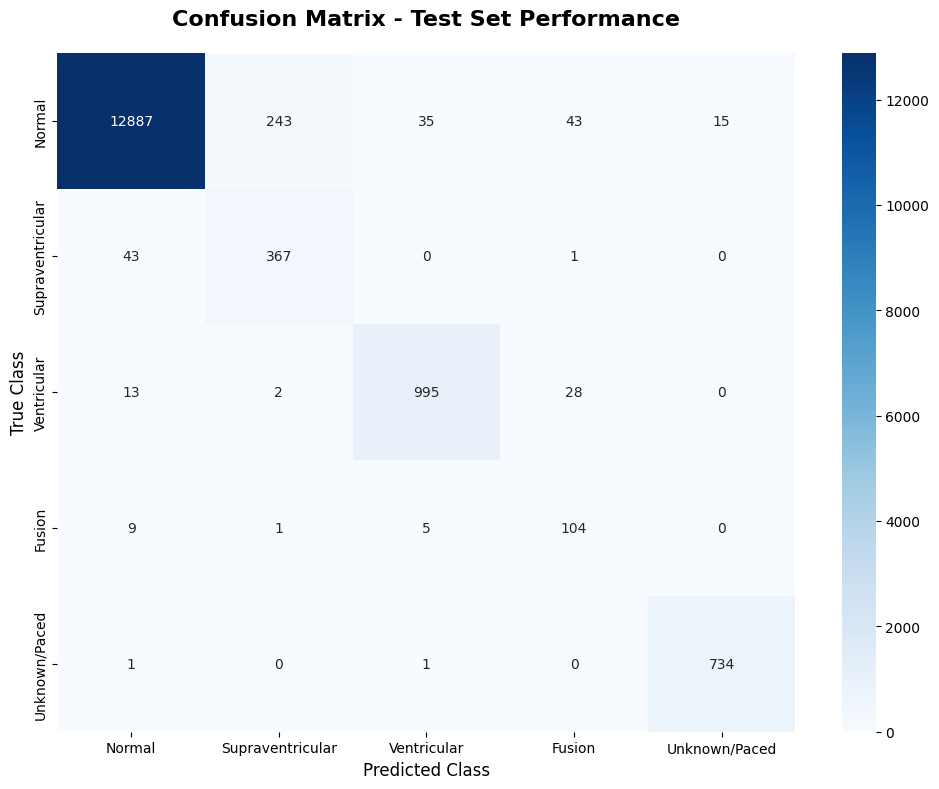


CONFUSION MATRIX INTERPRETATION
Diagonal values = Correct predictions
Off-diagonal values = Misclassifications

🎯 Focus on Class 2 (Ventricular) row:
   High values on diagonal = Good detection of dangerous beats
   High values off-diagonal = Missing dangerous beats (BAD!)


In [88]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Test Set Performance', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("CONFUSION MATRIX INTERPRETATION")
print("=" * 70)
print("Diagonal values = Correct predictions")
print("Off-diagonal values = Misclassifications")
print("\n🎯 Focus on Class 2 (Ventricular) row:")
print("   High values on diagonal = Good detection of dangerous beats")
print("   High values off-diagonal = Missing dangerous beats (BAD!)")

### 12.3 Detailed Classification Report

Per-class metrics showing precision, recall, and F1-score for each AAMI class.

In [90]:
# Generate classification report
print("=" * 70)
print("CLASSIFICATION REPORT - Per-Class Metrics")
print("=" * 70)
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

print("\n" + "=" * 70)
print("KEY METRICS EXPLAINED")
print("=" * 70)
print("Precision: Of all predicted arrhythmias, how many were correct?")
print("           → High precision = Few false alarms")
print("\nRecall:    Of all actual arrhythmias, how many did we detect?")
print("           → High recall = Catching dangerous beats")
print("\nF1-Score:  Balance between precision and recall")
print("           → Overall performance metric")
print("\n" + "=" * 70)
print("🎯 CRITICAL FOR CPET DEVICE")
print("=" * 70)
print("Focus on Class 2 (Ventricular) RECALL:")
print("  • High recall (>0.90) = Safe - catching dangerous beats")
print("  • Low recall (<0.70) = Dangerous - missing life-threatening arrhythmias")
print("\nFalse alarms (low precision) are acceptable - safety first!")

CLASSIFICATION REPORT - Per-Class Metrics
                  precision    recall  f1-score   support

          Normal     0.9949    0.9746    0.9846     13223
Supraventricular     0.5987    0.8929    0.7168       411
     Ventricular     0.9604    0.9586    0.9595      1038
          Fusion     0.5909    0.8739    0.7051       119
   Unknown/Paced     0.9800    0.9973    0.9886       736

        accuracy                         0.9717     15527
       macro avg     0.8250    0.9395    0.8709     15527
    weighted avg     0.9783    0.9717    0.9739     15527


KEY METRICS EXPLAINED
Precision: Of all predicted arrhythmias, how many were correct?
           → High precision = Few false alarms

Recall:    Of all actual arrhythmias, how many did we detect?
           → High recall = Catching dangerous beats

F1-Score:  Balance between precision and recall
           → Overall performance metric

🎯 CRITICAL FOR CPET DEVICE
Focus on Class 2 (Ventricular) RECALL:
  • High recall (>0.90) = Sa

### 12.4 Confidence Score Analysis

Analyze the model's confidence for correct vs incorrect predictions. This helps set the alert threshold for your CPET device.

C:\Users\USER\AppData\Local\Temp\ipykernel_15344\13759277.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([correct_confidence, incorrect_confidence],


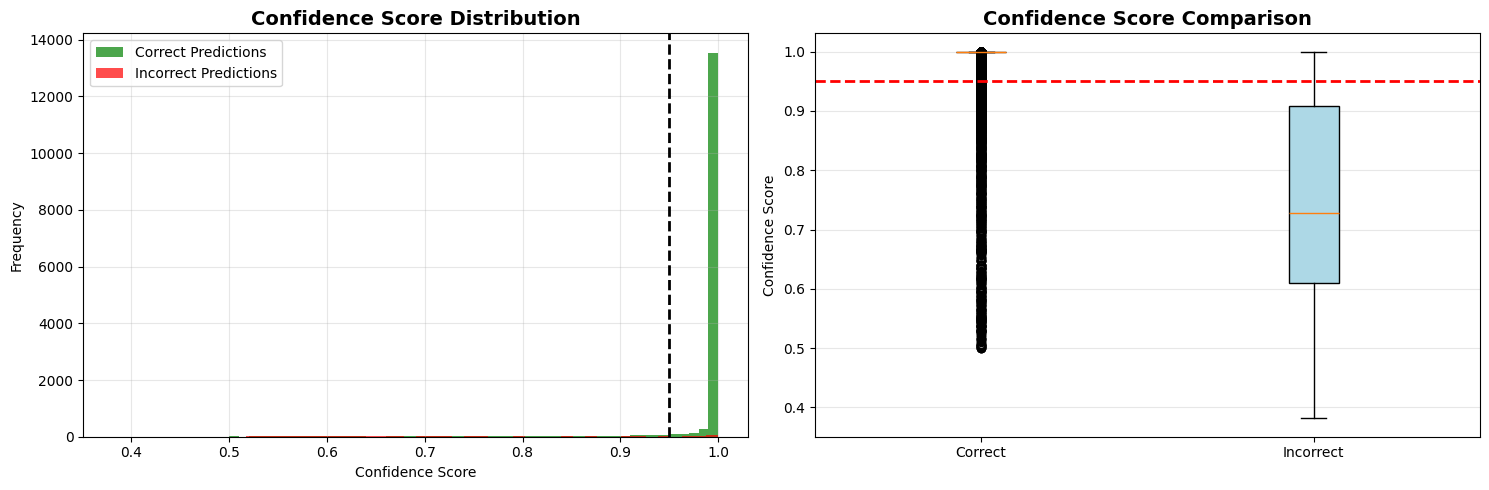

CONFIDENCE SCORE STATISTICS
Correct Predictions - Mean Confidence: 0.9864
Incorrect Predictions - Mean Confidence: 0.7511

Predictions above 95% confidence: 14,217 (91.6%)
Predictions below 95% confidence: 1,310 (8.4%)

💡 RECOMMENDATION FOR CPET DEVICE
Set 'Red Alert' threshold at 95% confidence:
  • Reduces false alarms during normal exercise
  • Still catches high-confidence dangerous arrhythmias
  • Can adjust threshold based on user risk profile


In [92]:
# Get confidence scores (max probability for each prediction)
confidence_scores = np.max(y_pred_probs, axis=1)

# Separate correct and incorrect predictions
correct_mask = (y_pred == y_test)
correct_confidence = confidence_scores[correct_mask]
incorrect_confidence = confidence_scores[~correct_mask]

# Plot confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(correct_confidence, bins=50, alpha=0.7, label='Correct Predictions', color='green')
axes[0].hist(incorrect_confidence, bins=50, alpha=0.7, label='Incorrect Predictions', color='red')
axes[0].set_title('Confidence Score Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axvline(x=0.95, color='black', linestyle='--', linewidth=2, label='95% Threshold')

# Box plot
axes[1].boxplot([correct_confidence, incorrect_confidence], 
                labels=['Correct', 'Incorrect'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Confidence Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Confidence Score')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% Threshold')

plt.tight_layout()
plt.show()

print("=" * 70)
print("CONFIDENCE SCORE STATISTICS")
print("=" * 70)
print(f"Correct Predictions - Mean Confidence: {np.mean(correct_confidence):.4f}")
print(f"Incorrect Predictions - Mean Confidence: {np.mean(incorrect_confidence):.4f}")
print(f"\nPredictions above 95% confidence: {np.sum(confidence_scores > 0.95):,} ({np.sum(confidence_scores > 0.95)/len(confidence_scores)*100:.1f}%)")
print(f"Predictions below 95% confidence: {np.sum(confidence_scores <= 0.95):,} ({np.sum(confidence_scores <= 0.95)/len(confidence_scores)*100:.1f}%)")

print("\n" + "=" * 70)
print("💡 RECOMMENDATION FOR CPET DEVICE")
print("=" * 70)
print("Set 'Red Alert' threshold at 95% confidence:")
print("  • Reduces false alarms during normal exercise")
print("  • Still catches high-confidence dangerous arrhythmias")
print("  • Can adjust threshold based on user risk profile")

## 13. Save Model for Deployment

Save the trained model for use in your 3,000 BDT CPET system.

In [93]:
# Save the final model
model_save_path = 'arrhythmia_cnn_final.keras'
cnn_model.save(model_save_path)

print("=" * 70)
print("MODEL SAVED FOR DEPLOYMENT")
print("=" * 70)
print(f"Model saved to: {model_save_path}")
print(f"Model size: {os.path.getsize(model_save_path) / (1024*1024):.2f} MB")

print("\n" + "=" * 70)
print("✅ PROJECT COMPLETE - READY FOR DEPLOYMENT")
print("=" * 70)
print("\n🎯 What You've Built:")
print("  ✅ Pan-Tompkins R-peak detection for precise centering")
print("  ✅ AAMI classification (5 standardized classes)")
print("  ✅ Balanced training data for fair learning")
print("  ✅ Lightweight 1D-CNN (~50K parameters)")
print("  ✅ Real-world evaluation on imbalanced test set")
print("  ✅ Confidence-based alert system")

print("\n🚀 Next Steps for Your 3,000 BDT CPET Device:")
print("  1. Deploy model on Raspberry Pi / laptop")
print("  2. Connect AD8232 ECG sensor")
print("  3. Implement real-time inference pipeline")
print("  4. Set up alert system with 95% confidence threshold")
print("  5. Test during actual exercise sessions")

print("\n💪 Your 'Deep Learning Weapon' is ready for arrhythmia detection!")

MODEL SAVED FOR DEPLOYMENT
Model saved to: arrhythmia_cnn_final.keras
Model size: 0.54 MB

✅ PROJECT COMPLETE - READY FOR DEPLOYMENT

🎯 What You've Built:
  ✅ Pan-Tompkins R-peak detection for precise centering
  ✅ AAMI classification (5 standardized classes)
  ✅ Balanced training data for fair learning
  ✅ Lightweight 1D-CNN (~50K parameters)
  ✅ Real-world evaluation on imbalanced test set
  ✅ Confidence-based alert system

🚀 Next Steps for Your 3,000 BDT CPET Device:
  1. Deploy model on Raspberry Pi / laptop
  2. Connect AD8232 ECG sensor
  3. Implement real-time inference pipeline
  4. Set up alert system with 95% confidence threshold
  5. Test during actual exercise sessions

💪 Your 'Deep Learning Weapon' is ready for arrhythmia detection!
